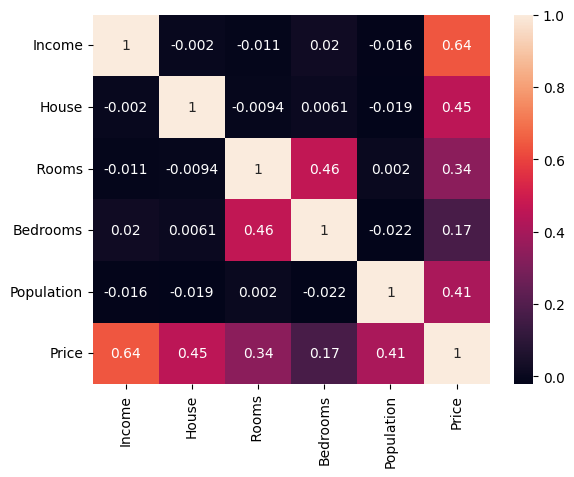

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# dataset load
df = pd.read_csv("USA_Housing.csv")

# Address column remove
df.drop(columns=['Address'], inplace=True, errors='ignore')

# float → int convert
df['Population'] = df['Population'].astype('int64')

# correlation matrix
corr = df.corr(numeric_only=True)

# heatmap
sns.heatmap(corr, annot=True,)

plt.show()

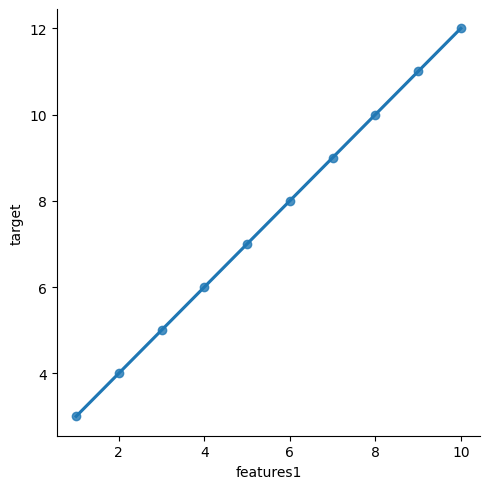

C:\Users\Omar Faruk\AppData\Local\Temp\ipykernel_8572\3254785568.py:47: UserWarning: you are shuffling a 'Series' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(new_col)


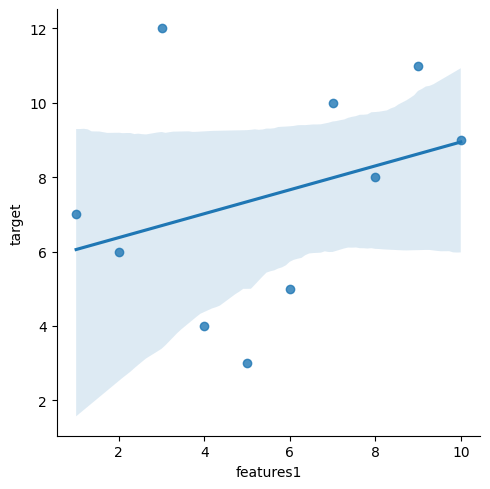

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.DataFrame({
    'features1': np.arange(1, 11),
    'features2': np.arange(2, 12),
    'target': np.arange(3, 13)
})

sns.lmplot(data=df, x='features1', y='target')

plt.show()


new_col = df['target'].copy()
np.random.shuffle(new_col)
df['target']=new_col

sns.lmplot(data=df, x='features1', y='target')

plt.show()

In [48]:
# =================================== Linear Regression ===============================
'''
Linear Regression - Important Formulas

1.  Simple Linear Regression y = mx + c

y = Predicted output x = Input feature m = Slope c = Intercept

2.  Slope Formula m = (nΣxy - (Σx)(Σy)) / (nΣx² - (Σx)²)

3.  Intercept Formula c = (Σy - mΣx) / n

4.  Prediction Formula ŷ = mx + c

5.  Mean Squared Error (MSE) J(m,c) = (1/n) Σ(y - ŷ)²

6.  Mean Absolute Error (MAE) MAE = (1/n) Σ|y - ŷ|

7.  Root Mean Squared Error (RMSE) RMSE = √[(1/n) Σ(y - ŷ)²]

8.  R² Score R² = 1 - [Σ(y - ŷ)² / Σ(y - ȳ)²]

9.  Gradient Descent m = m - α(∂J/∂m) c = c - α(∂J/∂c)

10. Multiple Linear Regression y = b0 + b1x1 + b2x2 + … + bnxn

11. Vector Form Y = Xβ + ε
'''


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# dataset load
df = pd.read_csv("USA_Housing.csv")

# Address column remove
df.drop(columns=['Address'], inplace=True, errors='ignore')

# float → int convert
df['Population'] = df['Population'].astype('int64')

# features and target
features = df.drop(columns=['Price'])
target = df['Price']

# split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# model training
model = LinearRegression()
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# revaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")



# scatter plot for actual vs predicted
# sns.scatterplot(x=y_test, y=y_pred)
# plt.show()

# coefficient or slope
# df = pd.DataFrame(index=X_train.columns, data=model.coef_, columns=['Coefficient'])
# df

# intercept
# model.intercept_



MAE: 80878.79115244081
MSE: 10088963923.433754
RMSE: 100443.83467109245


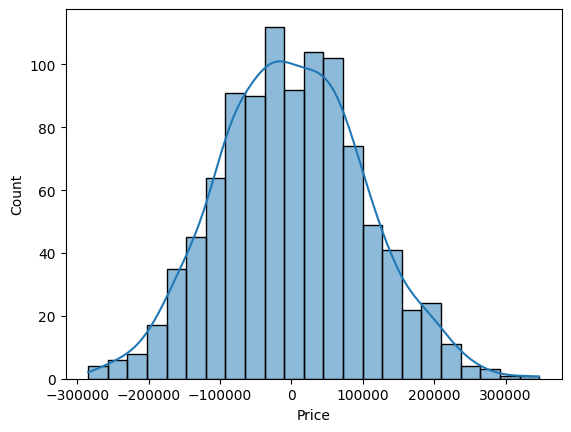

In [ ]:
# checking the residuals pred errors
sns.histplot(data=y_test - y_pred, kde=True)
plt.show()